# Ejercicios del Capítulo 7 – Reducción de Dimensionalidad

### 1. ¿Cuáles son las principales motivaciones para reducir la dimensionalidad de un conjunto de datos? ¿Cuáles son las principales desventajas?

La principales cosas positivas son que el dataset se vuel más ligero en memoria, reduce columnas, y mantiene aquella información con mayor varianza, por loq ue el entreno suele ser más rapido, las desventajas son que ahy peridda de información y que el resultado no es tan interpretable como el dataset original.


### 2. ¿Qué es la maldición de la dimensionalidad? 

que no se puede graficar, que el espacio se vuelve tan grande que los datos se vuelven escasos, y que el modelo se vuelve más complejo y propenso a sobreajustarse.


### 3. Una vez que se ha reducido la dimensionalidad de un conjunto de datos, ¿es posible revertir la operación? Si es así, ¿cómo? Si no, ¿por qué?

Si es pisible, pero con perdida de información, por ejemplo el PCA usa eigeenvetores, y para revertir sería una multiplicación de la matriz de componentes principales por la matriz de datos reducida, pero no se recuperará toda la información original debido a la reducción de dimensionalidad.


### 4. ¿Se puede utilizar PCA para reducir la dimensionalidad de un conjunto de datos altamente no lineal?

No, PCA es una tecnica para variables con correlación linearl, sin embargo existen algoritmos como LLE, Isomap o t-SNE que pueden manejar datos no lineales.


### 5. Supongamos que realizas PCA en un conjunto de datos de 1,000 dimensiones, estableciendo la relación de varianza explicada en el 95%. ¿Cuántas dimensiones tendrá el conjunto de datos resultante?

Depende totalmente de la varianza de las columnas del dataset, como puede ser 1 o 999, no hay una respuesta concreta a esta pregunta.


### 6. ¿En qué casos utilizarías PCA regular, PCA incremental, PCA aleatorizado (Randomized PCA) o Proyección Aleatoria (Random Projection)?

Utilizaría PCA regular para conjuntos pequeños, ademmás de para utilizarlo de forma para entrenar de primeras un modelo, el pexa incremental lo usaria para grandes conjuntos de datos donde constantemente estan entrando nuevo datos, PCA aleatorizado igual tiene un buen performances en datos grandes, y la proyección aleatoria para conjuntos de datos extremadamente grandes donde se necesita una reducción de dimensionalidad rápida y eficiente, aunque con una pérdida de precisión aceptable.

### 7. ¿Cómo puedes evaluar el rendimiento de un algoritmo de reducción de dimensionalidad en tu conjunto de datos?

Existen dos formas principales de evaluar el rendimiento:
1. **Error de reconstrucción**: Se mide la diferencia entre los datos originales y los datos después de aplicar la transformación inversa (si el algoritmo lo permite, como PCA). Si el error es bajo, el algoritmo retuvo la mayor parte de la información.
2. **Rendimiento en una tarea posterior**: Se entrena un modelo de Machine Learning (como un clasificador o regresor) con los datos reducidos y se comparan las métricas (precisión, RMSE, tiempo de entrenamiento) con el modelo entrenado con los datos originales. Si el rendimiento no cae significativamente (o incluso mejora debido a la eliminación de ruido), el algoritmo ha hecho un buen trabajo.
3. **Varianza explicada**: En técnicas como PCA, se puede observar el ratio de varianza explicada acumulada para ver cuánta información del dataset original se mantiene en las nuevas dimensiones.


### 8. ¿Tiene sentido encadenar dos algoritmos de reducción de dimensionalidad diferentes?

Sí, tiene mucho sentido en varios escenarios:
* **PCA + Algoritmo no lineal**: Es común usar PCA para reducir drásticamente el número de dimensiones primero (por ejemplo, a 50 dimensiones) y luego usar una técnica más costosa computacionalmente como t-SNE o LLE para bajar a 2 o 3 para visualización. Esto acelera el proceso y reduce el ruido.
* **Reducción de ruido + Especialización**: Se puede usar un algoritmo lineal para eliminar ruido y luego uno supervisado (como LDA) para maximizar la separación de clases en un espacio aún más pequeño.


## 9. Ejercicio de Programación: Clasificación en MNIST
Carga el conjunto de datos MNIST y divídelo en un conjunto de entrenamiento y uno de prueba (toma las primeras 60,000 instancias para entrenamiento y las 10,000 restantes para prueba). Entrena un clasificador de Random Forest en el conjunto de datos y mide cuánto tiempo tarda, luego evalúa el modelo resultante en el conjunto de prueba. A continuación, utiliza PCA para reducir la dimensionalidad del conjunto de datos con una relación de varianza explicada del 95%. Entrena un nuevo clasificador de Random Forest en el conjunto de datos reducido y observa cuánto tiempo tarda. ¿Fue el entrenamiento mucho más rápido? Luego, evalúa el clasificador en el conjunto de prueba. ¿Cómo se compara con el clasificador anterior? Inténtalo de nuevo con un `SGDClassifier`. ¿Cuánto ayuda el PCA en este caso?


In [4]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml

# Fetch the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data
y = mnist.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
                                                                      
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)


CPU times: total: 1min 12s
Wall time: 1min 15s


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
%%time
# Evaluate the model on the test set
accuracy = rf_clf.score(X_test, y_test)
print(f"Test set accuracy: {accuracy:.4f}")

Test set accuracy: 0.9705
CPU times: total: 578 ms
Wall time: 604 ms


#### Efecturar PCA y medir tiempo de entrenamiento y rendimiento en Random Forest:

In [8]:
# import pca
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality
pca = PCA(n_components=0.95)  # Retain 95% of the variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [9]:
%%time
# Train the Random Forest classifier on the PCA-transformed data
rf_clf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_pca.fit(X_train_pca, y_train)

CPU times: total: 3min 49s
Wall time: 3min 58s


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
%%time
# Evaluate the model on the test set
accuracy = rf_clf_pca.score(X_test_pca, y_test)
print(f"Test set accuracy: {accuracy:.4f}")

Test set accuracy: 0.9488
CPU times: total: 375 ms
Wall time: 391 ms


## 10. Ejercicio de Programación: Visualización con t-SNE
Utiliza t-SNE para reducir las primeras 5,000 imágenes del conjunto de datos MNIST a 2 dimensiones y grafica el resultado usando Matplotlib. Puedes usar un gráfico de dispersión con 10 colores diferentes para representar cada clase objetivo. Alternativamente, puedes reemplazar cada punto con la clase de la instancia (un dígito del 0 al 9), o incluso mostrar versiones reducidas de las imágenes de los dígitos. Deberías obtener una visualización agradable con grupos de dígitos bien separados. Intenta usar otros algoritmos de reducción de dimensionalidad, como PCA, LLE o MDS, y compara las visualizaciones resultantes.


In [12]:
X_sample, y_sample = X_train[:5000], y_train[:5000]

In [19]:
from sklearn.manifold import TSNE
import numpy as np

tsne = TSNE(n_components=2, init="random", learning_rate="auto",
            random_state=42)
%time X_reduced = tsne.fit_transform(X_sample)

CPU times: total: 2min 40s
Wall time: 22 s


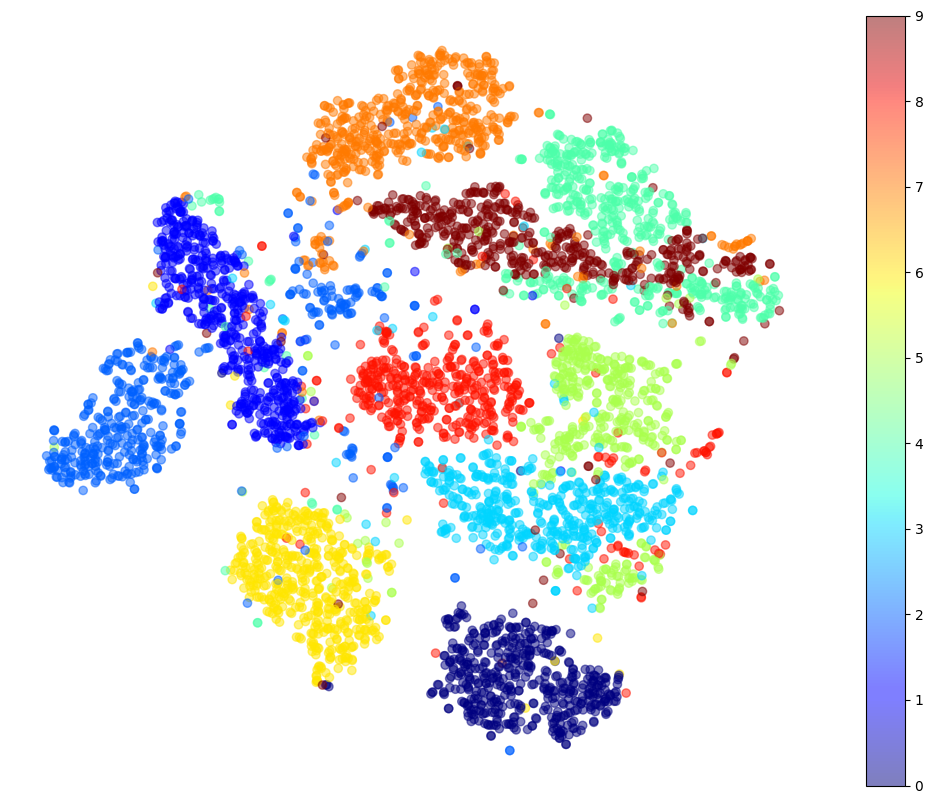

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()
plt.show()

CPU times: total: 234 ms
Wall time: 150 ms


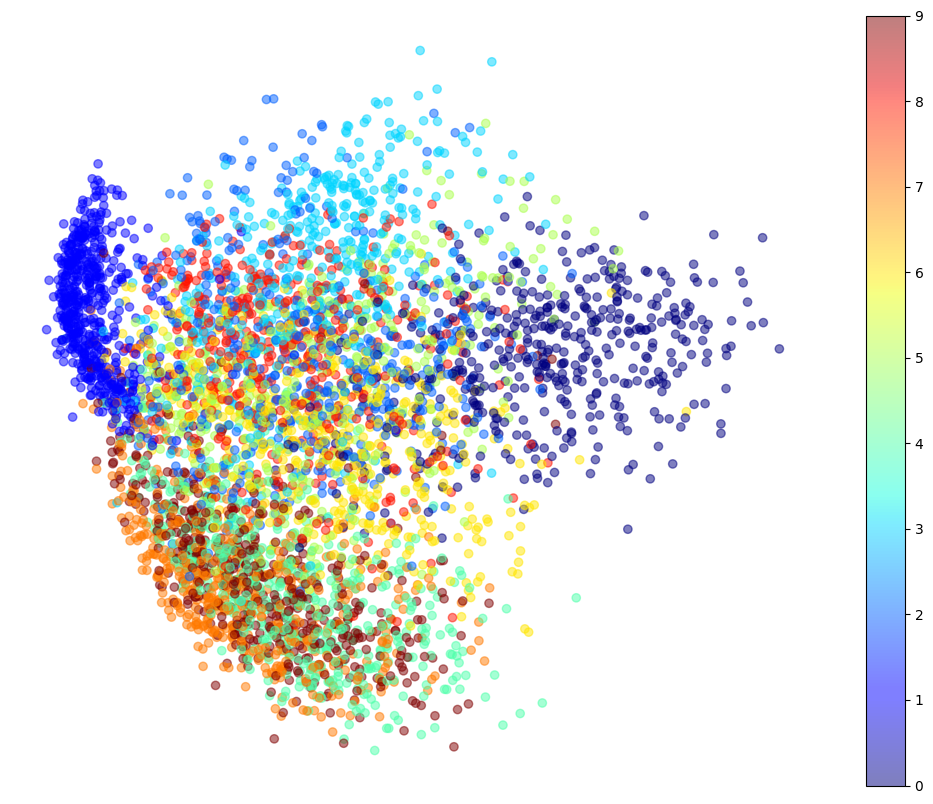

In [21]:
# probar con pca
pca = PCA(n_components=2)
%time X_reduced_pca = pca.fit_transform(X_sample)
plt.figure(figsize=(13, 10))
plt.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()
plt.show()

CPU times: total: 8.95 s
Wall time: 6.48 s


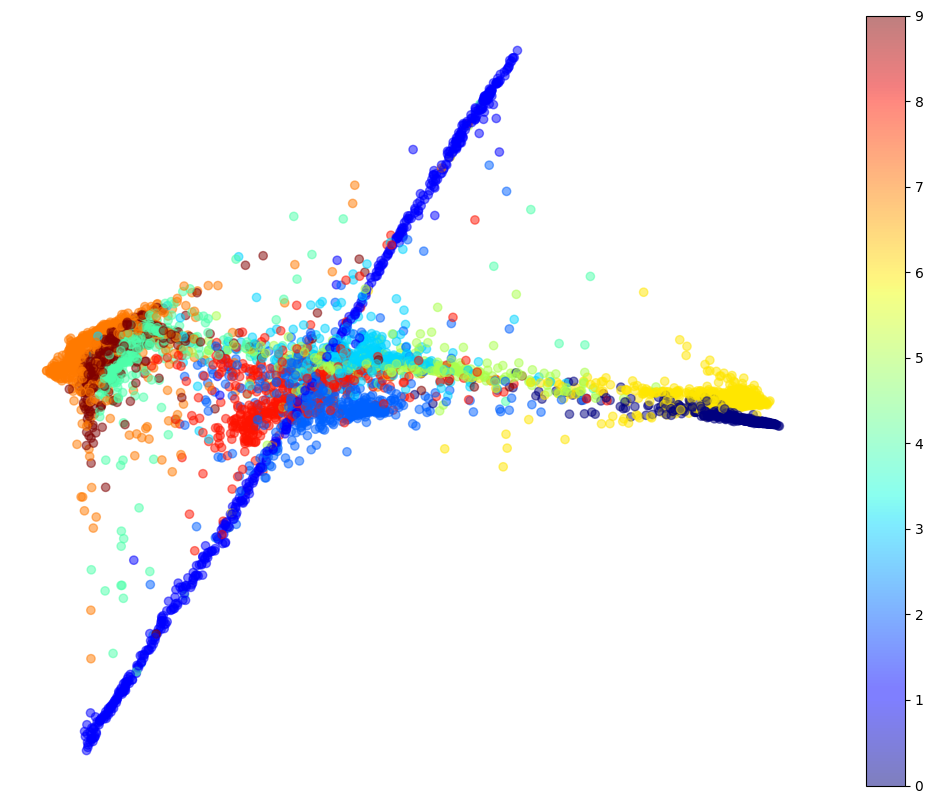

In [22]:
# prueba con LLE
from sklearn.manifold import LocallyLinearEmbedding
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
%time X_reduced_lle = lle.fit_transform(X_sample)
plt.figure(figsize=(13, 10))
plt.scatter(X_reduced_lle[:, 0], X_reduced_lle[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()
plt.show()

In [ ]:
from sklearn.pipeline import make_pipeline

pca_mds = make_pipeline(
    PCA(n_components=0.95, random_state=42),
    MDS(n_components=2, normalized_stress=False, random_state=42)
)
%time X_pca_mds_reduced = pca_mds.fit_transform(X_sample)


c:\Users\sergi\.venvs\ml-cuda\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


CPU times: total: 26min 22s
Wall time: 19min 5s


NameError: name 'plot_digits' is not defined

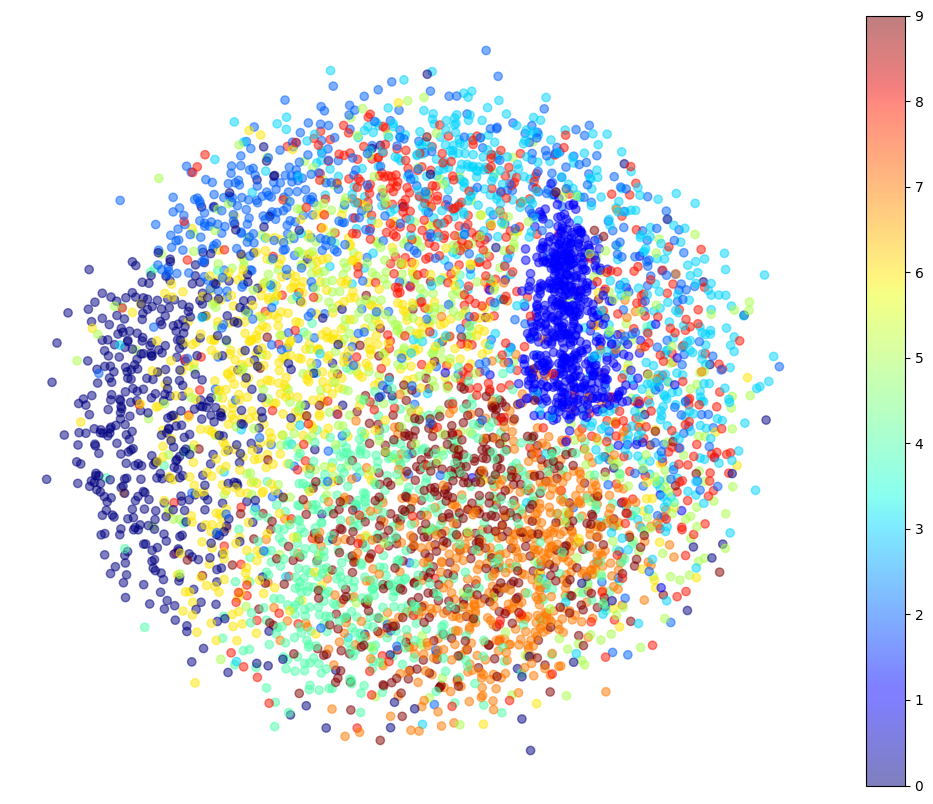

In [27]:
# do plot digfits

def plot_digits(X, y):
    plt.figure(figsize=(13, 10))
    plt.scatter(X[:, 0], X[:, 1],
                c=y.astype(np.int8), cmap="jet", alpha=0.5)
    plt.axis('off')
    plt.colorbar()

plot_digits(X_pca_mds_reduced, y_sample)
plt.show()